## 1️⃣ Environment Setup

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
import gc
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

print("\n" + "="*70)
print("💻 HARDWARE CONFIGURATION: RTX 4050 Laptop (6GB) + 16GB RAM")
print("="*70)

# GPU Configuration optimized for RTX 4050 Laptop (6GB VRAM)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            # Enable memory growth to avoid allocating all VRAM at once
            tf.config.experimental.set_memory_growth(gpu, True)
            
            # Set memory limit to 5GB (leaving 1GB buffer for system/Windows)
            tf.config.set_logical_device_configuration(
                gpu,
                [tf.config.LogicalDeviceConfiguration(memory_limit=5120)]
            )
        
        print(f"✅ GPU: {gpus[0].name}")
        print("   VRAM Limit: 5120 MB (5GB) - reserves 1GB for Windows")
        print("   Memory Growth: Enabled (dynamic allocation)")
        print("   Mixed Precision: Enabled (faster training on RTX 4050)")
        
        # Enable mixed precision for RTX 4050 (Tensor Cores acceleration)
        from tensorflow.keras import mixed_precision
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print("   ✅ Mixed Precision (FP16) enabled for faster training")
        
    except RuntimeError as e:
        print(f"⚠️ GPU config warning: {e}")
else:
    print("⚠️ No GPU found - using CPU (training will be much slower)")

# CPU Threading optimized for i5-13500HX (14 cores: 6P+8E)
# Use 8 threads for TensorFlow (leaving 6 cores for Windows/background tasks)
tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(4)

print(f"\n✅ CPU: i5-13500HX (14 cores)")
print(f"   Intra-op threads: 8 (leaves 6 cores for Windows)")
print(f"   Inter-op threads: 4 (parallel operations)")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Matplotlib settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Clear any existing sessions to free memory
keras.backend.clear_session()
gc.collect()

print("\n✅ Environment optimized for RTX 4050 Laptop!")
print("   - GPU Memory: 5GB allocated, 1GB reserved for Windows")
print("   - CPU: 8 threads active, 6 cores free for system")
print("   - RAM: ~4-6GB will be used, leaving 10GB+ for Windows")
print("="*70)


Python version: 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
TensorFlow version: 2.10.0
Keras version: 2.10.0

💻 HARDWARE CONFIGURATION: RTX 4050 Laptop (6GB) + 16GB RAM
✅ GPU: /physical_device:GPU:0
   VRAM Limit: 5120 MB (5GB) - reserves 1GB for Windows
   Memory Growth: Enabled (dynamic allocation)
   Mixed Precision: Enabled (faster training on RTX 4050)
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4050 Laptop GPU, compute capability 8.9
   ✅ Mixed Precision (FP16) enabled for faster training

✅ CPU: i5-13500HX (14 cores)
   Intra-op threads: 8 (leaves 6 cores for Windows)
   Inter-op threads: 4 (parallel operations)

✅ Environment optimized for RTX 4050 Laptop!
   - GPU Memory: 5GB allocated, 1GB reserved for Windows
   - CPU: 8 threads active, 6 cores free for system
   - RAM: ~4-6GB will be used

## 2️⃣ Configuration and Paths

In [2]:
from datetime import datetime
import json

NOTEBOOK_DIR = Path(os.getcwd())
DATASET_PATH = NOTEBOOK_DIR / "dataset-labeled"
OUTPUT_PATH = NOTEBOOK_DIR / "trained_model_improved"
OUTPUT_PATH.mkdir(exist_ok=True)

IMG_HEIGHT = 300
IMG_WIDTH = 300
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
IMG_CHANNELS = 3

# Optimized for RTX 4050 (6GB VRAM) + 16GB RAM system
BATCH_SIZE = 24  # Optimal for 6GB VRAM with mixed precision
EPOCHS = 50
LEARNING_RATE = 1e-4
VALIDATION_SPLIT = 0.2

# Data loading optimized for Windows + i5-13500HX CPU
MAX_QUEUE_SIZE = 10  # Larger queue for CPU preprocessing
WORKERS = 6  # Use 6 CPU threads for data loading (threading mode)
USE_MULTIPROCESSING = False  # Must be False on Windows/Jupyter to avoid pickle errors

CLASS_NAMES = ["fake", "real"]
NUM_CLASSES = len(CLASS_NAMES)

# PRIORITIZE FAKE DETECTION - Higher alpha focuses more on fake class
FOCAL_ALPHA = 0.75   # Focus MORE on fake class (minority class)
FOCAL_GAMMA = 2.0    # Moderate focusing on hard examples

# Lower threshold to catch more fakes (increase fake recall)
DECISION_THRESHOLD = 0.30  # Lower threshold = more sensitive to fake detection

print("="*70)
print("📊 TRAINING CONFIGURATION (RTX 4050 OPTIMIZED)")
print("="*70)
print(f"Dataset path: {DATASET_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Image size: {IMG_SIZE}")
print(f"\n🖥️ HARDWARE-OPTIMIZED SETTINGS:")
print(f"  Batch size: {BATCH_SIZE} (optimal for 6GB VRAM + FP16)")
print(f"  Epochs (Phase 1): {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Data workers: {WORKERS} threads (threading mode for Windows)")
print(f"  Queue size: {MAX_QUEUE_SIZE} (buffered data loading)")
print(f"  Multiprocessing: {USE_MULTIPROCESSING} (threading mode - Windows compatible)")
print(f"\n⚡ PERFORMANCE OPTIMIZATIONS:")
print(f"  • Mixed Precision (FP16) - 2x faster training on RTX 4050")
print(f"  • GPU Memory Limit: 5GB (1GB reserved for Windows)")
print(f"  • CPU Threads: 8 active, 6 free for system tasks")
print(f"  • Expected RAM usage: 4-6GB (10GB+ free for Windows)")
print(f"\n🎯 FAKE-PRIORITIZED SETTINGS (High Fake Recall):")
print(f"  Focal Loss alpha: {FOCAL_ALPHA} (prioritize fake class)")
print(f"  Focal Loss gamma: {FOCAL_GAMMA}")
print(f"  Decision threshold: {DECISION_THRESHOLD} (sensitive to fakes)")
print(f"\n🎯 PRIMARY TARGET: Fake Recall >90%")
print(f"🎯 SECONDARY TARGET: Real Recall >80%")
print("="*70)


📊 TRAINING CONFIGURATION (RTX 4050 OPTIMIZED)
Dataset path: C:\Users\RAJU\Desktop\Tested MP\simply copied - 1\AI-models\dataset-labeled
Output path: C:\Users\RAJU\Desktop\Tested MP\simply copied - 1\AI-models\trained_model_improved
Image size: (300, 300)

🖥️ HARDWARE-OPTIMIZED SETTINGS:
  Batch size: 24 (optimal for 6GB VRAM + FP16)
  Epochs (Phase 1): 50
  Learning rate: 0.0001
  Data workers: 6 threads (threading mode for Windows)
  Queue size: 10 (buffered data loading)
  Multiprocessing: False (threading mode - Windows compatible)

⚡ PERFORMANCE OPTIMIZATIONS:
  • Mixed Precision (FP16) - 2x faster training on RTX 4050
  • GPU Memory Limit: 5GB (1GB reserved for Windows)
  • CPU Threads: 8 active, 6 free for system tasks
  • Expected RAM usage: 4-6GB (10GB+ free for Windows)

🎯 FAKE-PRIORITIZED SETTINGS (High Fake Recall):
  Focal Loss alpha: 0.75 (prioritize fake class)
  Focal Loss gamma: 2.0
  Decision threshold: 0.3 (sensitive to fakes)

🎯 PRIMARY TARGET: Fake Recall >90%
🎯 SEC

## 3️⃣ Check Dataset Structure & Compute Class Weights

In [3]:
def check_dataset_and_calculate_weights(dataset_path):
    print("\n🔍 Analyzing dataset...\n")
    
    if not dataset_path.exists():
        print(f"❌ ERROR: Dataset path not found: {dataset_path}")
        return False, None
    
    real_folder = dataset_path / "real"
    fake_folder = dataset_path / "fake"
    
    if not (real_folder.exists() and fake_folder.exists()):
        print("❌ ERROR: Dataset structure incorrect! Expected 'real' and 'fake' folders.")
        return False, None
    
    real_images = list(real_folder.rglob("*.jpg")) + list(real_folder.rglob("*.jpeg")) + list(real_folder.rglob("*.png"))
    fake_images = list(fake_folder.rglob("*.jpg")) + list(fake_folder.rglob("*.jpeg")) + list(fake_folder.rglob("*.png"))
    
    n_fake = len(fake_images)
    n_real = len(real_images)
    total = n_fake + n_real
    
    if total == 0:
        print("❌ ERROR: No images found in dataset.")
        return False, None
    
    print("✅ Dataset structure is CORRECT!")
    print(f"\n📁 Real images: {n_real:,} ({n_real/total*100:.1f}%)")
    print(f"📁 Fake images: {n_fake:,} ({n_fake/total*100:.1f}%)")
    print(f"📁 Total images: {total:,}")
    
    imbalance_ratio = n_real / n_fake if n_fake > 0 else 0
    print(f"\n⚖️  Class Imbalance Ratio (real:fake) ≈ {imbalance_ratio:.2f}:1")
    
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),  # fake=0, real=1
        y=np.array([0]*n_fake + [1]*n_real)
    )
    
    class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}
    
    print("\n🎯 Computed Class Weights:")
    print(f"   • Fake class weight (0): {class_weight_dict[0]:.3f}")
    print(f"   • Real class weight (1): {class_weight_dict[1]:.3f}")
    print(f"   → Missing fakes is penalized ≈ {class_weight_dict[0]/class_weight_dict[1]:.1f}x more than missing real!")
    
    return True, class_weight_dict

dataset_ready, class_weights = check_dataset_and_calculate_weights(DATASET_PATH)

if not dataset_ready:
    print("\n⛔ CANNOT PROCEED - Fix dataset path/structure.")
else:
    print("\n✅ Dataset ready. Proceed to data generators.")


🔍 Analyzing dataset...

✅ Dataset structure is CORRECT!

📁 Real images: 7,426 (60.0%)
📁 Fake images: 4,952 (40.0%)
📁 Total images: 12,378

⚖️  Class Imbalance Ratio (real:fake) ≈ 1.50:1

🎯 Computed Class Weights:
   • Fake class weight (0): 1.250
   • Real class weight (1): 0.833
   → Missing fakes is penalized ≈ 1.5x more than missing real!

✅ Dataset ready. Proceed to data generators.
✅ Dataset structure is CORRECT!

📁 Real images: 7,426 (60.0%)
📁 Fake images: 4,952 (40.0%)
📁 Total images: 12,378

⚖️  Class Imbalance Ratio (real:fake) ≈ 1.50:1

🎯 Computed Class Weights:
   • Fake class weight (0): 1.250
   • Real class weight (1): 0.833
   → Missing fakes is penalized ≈ 1.5x more than missing real!

✅ Dataset ready. Proceed to data generators.


## 4️⃣ Data Generators with Augmentation

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode="nearest",
    validation_split=VALIDATION_SPLIT
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VALIDATION_SPLIT
)

print("Creating data generators (Windows threading mode)...\n")

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    subset="training",
    shuffle=True,
    seed=SEED
)

validation_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    subset="validation",
    shuffle=False,
    seed=SEED
)

print("\n" + "="*70)
print("📊 DATA GENERATORS READY (RTX 4050 OPTIMIZED)")
print("="*70)
print(f"Training samples:   {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Classes:            {train_generator.class_indices}")
print(f"Batch size:         {BATCH_SIZE} (fits in 5GB VRAM with FP16)")
print(f"Steps/epoch:        {train_generator.samples // BATCH_SIZE}")
print(f"Validation steps:   {validation_generator.samples // BATCH_SIZE}")
print(f"\n⚡ Data Loading Performance:")
print(f"  • Worker threads: {WORKERS} (threading mode - Windows compatible)")
print(f"  • Queue size: {MAX_QUEUE_SIZE} (buffered batches)")
print(f"  • Mode: Threading (avoids Windows multiprocessing pickle errors)")
print("="*70)


Creating data generators (Windows threading mode)...

Found 9903 images belonging to 2 classes.
Found 9903 images belonging to 2 classes.
Found 2475 images belonging to 2 classes.
Found 2475 images belonging to 2 classes.

📊 DATA GENERATORS READY (RTX 4050 OPTIMIZED)
Training samples:   9903
Validation samples: 2475
Classes:            {'fake': 0, 'real': 1}
Batch size:         24 (fits in 5GB VRAM with FP16)
Steps/epoch:        412
Validation steps:   103

⚡ Data Loading Performance:
  • Worker threads: 6 (threading mode - Windows compatible)
  • Queue size: 10 (buffered batches)
  • Mode: Threading (avoids Windows multiprocessing pickle errors)

📊 DATA GENERATORS READY (RTX 4050 OPTIMIZED)
Training samples:   9903
Validation samples: 2475
Classes:            {'fake': 0, 'real': 1}
Batch size:         24 (fits in 5GB VRAM with FP16)
Steps/epoch:        412
Validation steps:   103

⚡ Data Loading Performance:
  • Worker threads: 6 (threading mode - Windows compatible)
  • Queue size: 1

## 5️⃣ Focal Loss Definition

In [5]:
def focal_loss(alpha=0.75, gamma=2.0):
    """Focal Loss for imbalanced classification.
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        focal_weight = tf.pow(1 - y_pred, gamma)
        alpha_weight = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_ce = alpha_weight * focal_weight * ce
        return tf.reduce_mean(tf.reduce_sum(focal_ce, axis=-1))
    return loss_fn

print("✅ Focal Loss defined")
print(f"   alpha: {FOCAL_ALPHA}")
print(f"   gamma: {FOCAL_GAMMA}")

✅ Focal Loss defined
   alpha: 0.75
   gamma: 2.0


## 6️⃣ Build EfficientNetB3 Model (High-Accuracy Version)

In [6]:
def build_high_accuracy_model(input_shape=(300, 300, 3), num_classes=2):
    print("\n🏗️ Building EfficientNetB3 high-accuracy model...\n")
    base_model = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.BatchNormalization(name="batch_norm_1")(x)

    # Optimized architecture for balanced high performance
    x = layers.Dropout(0.5, name="dropout_1")(x)
    x = layers.Dense(1024, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001), name="dense_1")(x)
    x = layers.BatchNormalization(name="batch_norm_2")(x)
    x = layers.Dropout(0.4, name="dropout_2")(x)
    x = layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001), name="dense_2")(x)
    x = layers.BatchNormalization(name="batch_norm_3")(x)
    x = layers.Dropout(0.3, name="dropout_3")(x)
    x = layers.Dense(256, activation="relu", name="dense_3")(x)
    x = layers.Dropout(0.2, name="dropout_4")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs, outputs, name="HighAccuracyFakeDetection_B3")
    return model, base_model

model, base_model = build_high_accuracy_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    num_classes=NUM_CLASSES
)

model.summary()

print("\n" + "="*70)
print("✅ MODEL ARCHITECTURE READY")
print("="*70)
print(f"Total parameters:    {model.count_params():,}")
print(f"Trainable parameters: {sum(int(tf.size(w)) for w in model.trainable_weights):,}")
print("="*70)



🏗️ Building EfficientNetB3 high-accuracy model...

Model: "HighAccuracyFakeDetection_B3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 300, 300, 3)]     0         
Model: "HighAccuracyFakeDetection_B3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 300, 300, 3)]     0         
                                                                 
                                                                 
 efficientnetb3 (Functional)  (None, 10, 10, 1536)     10783535  
                                                                 
 global_avg_pool (GlobalAver  (None, 1536)             0         
 agePooling2D)                                                   
                                                                 
 batch_norm_1 

## 7️⃣ Compile Model with Focal Loss

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA),
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

print("✅ Model compiled with Focal Loss")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Focal alpha:   {FOCAL_ALPHA}")
print(f"   Focal gamma:   {FOCAL_GAMMA}")

✅ Model compiled with Focal Loss
   Learning rate: 0.0001
   Focal alpha:   0.75
   Focal gamma:   2.0

   Learning rate: 0.0001
   Focal alpha:   0.75
   Focal gamma:   2.0


## 8️⃣ Callbacks (EarlyStopping & ReduceLROnPlateau)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",   # Monitor validation loss for better generalization
    patience=12,  # Increased patience for better convergence
    mode="min",
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,  # More aggressive LR reduction
    patience=5,
    min_lr=1e-8,
    mode="min",
    verbose=1
)

callbacks_list = [early_stop, reduce_lr]

print("="*70)
print("✅ CALLBACKS READY")
print("="*70)
print("EarlyStopping:  monitor=val_loss, patience=12")
print("ReduceLROnPlateau: monitor=val_loss, patience=5, factor=0.3")
print("="*70)


✅ CALLBACKS READY
EarlyStopping:  monitor=val_loss, patience=12
ReduceLROnPlateau: monitor=val_loss, patience=5, factor=0.3

✅ CALLBACKS READY
EarlyStopping:  monitor=val_loss, patience=12
ReduceLROnPlateau: monitor=val_loss, patience=5, factor=0.3


## 9️⃣ Phase 1 Training (Frozen Base)

In [9]:
print("\n" + "="*70)
print("🚀 STARTING PHASE 1 TRAINING (RTX 4050 OPTIMIZED)")
print("="*70)
print(f"Epochs:      {EPOCHS}")
print(f"Batch size:  {BATCH_SIZE} (optimal for 6GB VRAM)")
print(f"Class weights: {class_weights}")
print(f"Mixed Precision: Enabled (FP16 - 2x faster on RTX 4050)")
print(f"Expected time: ~{(train_generator.samples // BATCH_SIZE) * 0.5:.0f}-{(train_generator.samples // BATCH_SIZE) * 0.8:.0f} sec/epoch")
print("="*70 + "\n")

# Free up memory before training
gc.collect()
tf.keras.backend.clear_session()

history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1,
    max_queue_size=MAX_QUEUE_SIZE,
    workers=WORKERS,
    use_multiprocessing=USE_MULTIPROCESSING
)

history_phase1_df = pd.DataFrame(history_phase1.history)
history_phase1_df["epoch"] = range(1, len(history_phase1_df) + 1)
history_phase1_df.to_csv(OUTPUT_PATH / "training_history_phase1_high_accuracy.csv", index=False)
print("\n✅ Phase 1 history saved -> training_history_phase1_high_accuracy.csv")

print("\n" + "="*70)
print("✅ PHASE 1 TRAINING COMPLETE")
print("="*70)

# Free memory after Phase 1
gc.collect()



🚀 STARTING PHASE 1 TRAINING (RTX 4050 OPTIMIZED)
Epochs:      50
Batch size:  24 (optimal for 6GB VRAM)
Class weights: {0: 1.2497980613893376, 1: 0.8334231079989227}
Mixed Precision: Enabled (FP16 - 2x faster on RTX 4050)
Expected time: ~206-330 sec/epoch

Epoch 1/50
Epoch 1/50
413/413 [==============================] - 272s 593ms/step - loss: 2.1834 - accuracy: 0.6192 - precision: 0.6192 - recall: 0.6187 - auc: 0.6577 - val_loss: 2.0620 - val_accuracy: 0.6638 - val_precision: 0.6641 - val_recall: 0.6638 - val_auc: 0.7496 - lr: 1.0000e-04
Epoch 2/50
Epoch 2/50
413/413 [==============================] - 243s 586ms/step - loss: 2.0585 - accuracy: 0.6605 - precision: 0.6606 - recall: 0.6602 - auc: 0.7213 - val_loss: 1.9871 - val_accuracy: 0.6723 - val_precision: 0.6725 - val_recall: 0.6719 - val_auc: 0.7573 - lr: 1.0000e-04
Epoch 3/50
Epoch 3/50
413/413 [==============================] - 244s 589ms/step - loss: 1.9780 - accuracy: 0.6765 - precision: 0.6769 - recall: 0.6764 - auc: 0.7429 

417

## 9️⃣.5️⃣ Save Phase 1 Weights & Config

In [10]:
weights_path_phase1 = OUTPUT_PATH / "model_phase1_high_accuracy_weights.h5"
model.save_weights(str(weights_path_phase1))
print(f"✅ Phase 1 weights saved to: {weights_path_phase1}")

# Note: Skipping SavedModel format due to mixed precision JSON serialization issue
# The .h5 weights file is sufficient - you can rebuild the model and load weights
print("ℹ️  SavedModel skipped (mixed precision incompatibility)")
print("   Use Method 2 in final cell to reload: rebuild model + load .h5 weights")

config_phase1 = {
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "decision_threshold": DECISION_THRESHOLD,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "image_size": list(IMG_SIZE),  # Convert tuple to list for JSON
    "class_names": CLASS_NAMES,
    "phase": "phase1_high_accuracy",
    "mixed_precision": "mixed_float16",
    "model_name": "HighAccuracyFakeDetection_B3"
}
config_path_phase1 = OUTPUT_PATH / "model_phase1_high_accuracy_config.json"
with open(config_path_phase1, "w") as f:
    json.dump(config_phase1, f, indent=2)
print(f"✅ Phase 1 config saved to: {config_path_phase1.name}")


✅ Phase 1 weights saved to: C:\Users\RAJU\Desktop\Tested MP\simply copied - 1\AI-models\trained_model_improved\model_phase1_high_accuracy_weights.h5
ℹ️  SavedModel skipped (mixed precision incompatibility)
   Use Method 2 in final cell to reload: rebuild model + load .h5 weights
✅ Phase 1 config saved to: model_phase1_high_accuracy_config.json


## 🔟 Phase 2: Fine-Tuning (Unfreeze Last 30 Layers)

In [11]:
# Free memory before Phase 2
gc.collect()
tf.keras.backend.clear_session()

# Unfreeze last 50 layers for more fine-tuning capacity
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"\n🔓 Unfrozen last 50 layers of EfficientNetB3")
print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Trainable layers in base:  {trainable_layers}")

FINE_TUNE_LR = LEARNING_RATE / 5  # Less aggressive LR reduction
FINE_TUNE_EPOCHS = 30  # More fine-tuning epochs

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=focal_loss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA),
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

print(f"\n✅ Model recompiled for fine-tuning with LR={FINE_TUNE_LR}")
print("\n" + "="*70)
print("🚀 STARTING PHASE 2 FINE-TUNING (RTX 4050 OPTIMIZED)")
print("="*70)
print(f"Fine-tune epochs: {FINE_TUNE_EPOCHS}")
print(f"Learning rate:    {FINE_TUNE_LR}")
print(f"Unfrozen layers:  50 (more capacity for learning)")
print(f"Batch size:       {BATCH_SIZE} (fits in 5GB VRAM)")
print(f"Mixed Precision:  Enabled (FP16 acceleration)")
print(f"Expected time:    ~{(train_generator.samples // BATCH_SIZE) * 0.6:.0f}-{(train_generator.samples // BATCH_SIZE) * 1.0:.0f} sec/epoch (slower due to backprop)")
print("="*70)



🔓 Unfrozen last 50 layers of EfficientNetB3
Total layers in base model: 385
Trainable layers in base:  50

✅ Model recompiled for fine-tuning with LR=2e-05

🚀 STARTING PHASE 2 FINE-TUNING (RTX 4050 OPTIMIZED)
Fine-tune epochs: 30
Learning rate:    2e-05
Unfrozen layers:  50 (more capacity for learning)
Batch size:       24 (fits in 5GB VRAM)
Mixed Precision:  Enabled (FP16 acceleration)
Expected time:    ~247-412 sec/epoch (slower due to backprop)


In [12]:
history_phase2 = model.fit(
    train_generator,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1,
    max_queue_size=MAX_QUEUE_SIZE,
    workers=WORKERS,
    use_multiprocessing=USE_MULTIPROCESSING
)

history_phase2_df = pd.DataFrame(history_phase2.history)
history_phase2_df["epoch"] = range(1, len(history_phase2_df) + 1)
history_phase2_df.to_csv(OUTPUT_PATH / "training_history_phase2_high_accuracy.csv", index=False)
print("\n✅ Phase 2 history saved -> training_history_phase2_high_accuracy.csv")

print("\n" + "="*70)
print("✅ PHASE 2 FINE-TUNING COMPLETE")
print("="*70)

# Free memory after Phase 2
gc.collect()


Epoch 1/30
413/413 [==============================] - 276s 610ms/step - loss: 0.1087 - accuracy: 0.9029 - precision: 0.9029 - recall: 0.9027 - auc: 0.9681 - val_loss: 0.2112 - val_accuracy: 0.7022 - val_precision: 0.7025 - val_recall: 0.7022 - val_auc: 0.7991 - lr: 2.0000e-05
Epoch 2/30
Epoch 2/30
413/413 [==============================] - 252s 608ms/step - loss: 0.1020 - accuracy: 0.9166 - precision: 0.9169 - recall: 0.9164 - auc: 0.9752 - val_loss: 0.2067 - val_accuracy: 0.7143 - val_precision: 0.7142 - val_recall: 0.7139 - val_auc: 0.8113 - lr: 2.0000e-05
Epoch 3/30
Epoch 3/30
413/413 [==============================] - 248s 597ms/step - loss: 0.0988 - accuracy: 0.9250 - precision: 0.9251 - recall: 0.9249 - auc: 0.9777 - val_loss: 0.2097 - val_accuracy: 0.7107 - val_precision: 0.7105 - val_recall: 0.7099 - val_auc: 0.8038 - lr: 2.0000e-05
Epoch 4/30
Epoch 4/30
413/413 [==============================] - 245s 590ms/step - loss: 0.0925 - accuracy: 0.9322 - precision: 0.9324 - recall: 0.

487

## 🔟.2️⃣ Save Final (Phase 2) Weights & Config

In [21]:
weights_path_phase2 = OUTPUT_PATH / "model_phase2_high_accuracy_weights.h5"
model.save_weights(str(weights_path_phase2))
print(f"✅ Final (Phase 2) weights saved to: {weights_path_phase2}")

# Note: Skipping SavedModel format due to mixed precision JSON serialization issue
# The .h5 weights file is sufficient - you can rebuild the model and load weights
print("ℹ️  SavedModel skipped (mixed precision incompatibility)")
print("   Use Method 2 in final cell to reload: rebuild model + load .h5 weights")

config_phase2 = {
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "decision_threshold": DECISION_THRESHOLD,
    "learning_rate_phase1": LEARNING_RATE,
    "learning_rate_phase2": FINE_TUNE_LR,
    "batch_size": BATCH_SIZE,
    "image_size": list(IMG_SIZE),  # Convert tuple to list for JSON
    "class_names": CLASS_NAMES,
    "unfrozen_layers": 50,
    "phase": "phase2_high_accuracy",
    "mixed_precision": "mixed_float16",
    "model_name": "HighAccuracyFakeDetection_B3",
    "target_metrics": {
        "fake_recall": ">80%",
        "real_recall": ">80%",
        "overall_accuracy": ">80%",
        "overall_precision": ">80%"
    }
}
config_path_phase2 = OUTPUT_PATH / "model_phase2_high_accuracy_config.json"
with open(config_path_phase2, "w") as f:
    json.dump(config_phase2, f, indent=2)
print(f"✅ Final config saved to: {config_path_phase2.name}")


✅ Final (Phase 2) weights saved to: C:\Users\RAJU\Desktop\Tested MP\simply copied - 1\AI-models\trained_model_improved\model_phase2_high_accuracy_weights.h5
ℹ️  SavedModel skipped (mixed precision incompatibility)
   Use Method 2 in final cell to reload: rebuild model + load .h5 weights
✅ Final config saved to: model_phase2_high_accuracy_config.json


## 1️⃣1️⃣ Evaluation with Standard and Custom Threshold

In [22]:
print("Using best model (weights restored by EarlyStopping)")
best_model = model

print("\n" + "="*70)
print("📊 PREDICTING ON VALIDATION SET")
print("="*70)

validation_generator.reset()
y_pred_probs = best_model.predict(validation_generator, verbose=1)
y_true = validation_generator.classes

# Standard prediction (argmax at 0.5)
y_pred_standard = np.argmax(y_pred_probs, axis=1)

# Custom threshold on fake probability
fake_probs = y_pred_probs[:, 0]
fake_pred_flag = (fake_probs > DECISION_THRESHOLD).astype(int)
y_pred_custom = np.where(fake_pred_flag == 1, 0, 1)  # 0=fake, 1=real

print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT - STANDARD (0.5)")
print("="*70)
print(classification_report(y_true, y_pred_standard, target_names=CLASS_NAMES, digits=4))

print("\n" + "="*70)
print(f"📊 CLASSIFICATION REPORT - CUSTOM THRESHOLD ({DECISION_THRESHOLD})")
print("="*70)
print(classification_report(y_true, y_pred_custom, target_names=CLASS_NAMES, digits=4))

f1_standard = f1_score(y_true, y_pred_standard, average=None)
f1_custom = f1_score(y_true, y_pred_custom, average=None)

print("\n" + "="*70)
print("🎯 F1-SCORE COMPARISON (Fake=class 0, Real=class 1)")
print("="*70)
print(f"Fake F1 (standard): {f1_standard[0]:.4f}")
print(f"Fake F1 (custom):   {f1_custom[0]:.4f}")
print(f"Real F1 (standard): {f1_standard[1]:.4f}")
print(f"Real F1 (custom):   {f1_custom[1]:.4f}")

use_custom = f1_custom.mean() >= f1_standard.mean()
y_pred_final = y_pred_custom if use_custom else y_pred_standard
threshold_used = DECISION_THRESHOLD if use_custom else 0.5
print(f"\n✅ Using {'custom' if use_custom else 'standard'} threshold = {threshold_used} for following plots")

Using best model (weights restored by EarlyStopping)

📊 PREDICTING ON VALIDATION SET
104/104 [==============================] - 50s 473ms/step

📊 CLASSIFICATION REPORT - STANDARD (0.5)
              precision    recall  f1-score   support

        fake     0.7930    0.3869    0.5200       990
        real     0.6953    0.9327    0.7967      1485

    accuracy                         0.7143      2475
   macro avg     0.7441    0.6598    0.6583      2475
weighted avg     0.7344    0.7143    0.6860      2475


📊 CLASSIFICATION REPORT - CUSTOM THRESHOLD (0.3)
              precision    recall  f1-score   support

        fake     0.6866    0.7414    0.7130       990
        real     0.8179    0.7744    0.7956      1485

    accuracy                         0.7612      2475
   macro avg     0.7523    0.7579    0.7543      2475
weighted avg     0.7654    0.7612    0.7625      2475


🎯 F1-SCORE COMPARISON (Fake=class 0, Real=class 1)
Fake F1 (standard): 0.5200
Fake F1 (custom):   0.7130
Real 

In [29]:
# Generate detailed classification report
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Calculate overall metrics
overall_accuracy = accuracy_score(y_true, y_pred_final)
overall_precision = precision_score(y_true, y_pred_final, average='weighted')
overall_recall = recall_score(y_true, y_pred_final, average='weighted')

# Per-class metrics
fake_recall = recall_score(y_true, y_pred_final, pos_label=0)
real_recall = recall_score(y_true, y_pred_final, pos_label=1)
fake_precision = precision_score(y_true, y_pred_final, pos_label=0)
real_precision = precision_score(y_true, y_pred_final, pos_label=1)

print("\n" + "="*70)
print("🎯 FAKE-PRIORITIZED DETECTION - PERFORMANCE METRICS")
print("="*70)
print(f"\n{'METRIC':<30} {'VALUE':<15} {'TARGET':<20} {'STATUS':<10}")
print("-" * 75)

# PRIMARY TARGETS (Most Important)
print("PRIMARY TARGETS (Critical):")
fake_rec_status = "✅ PASS" if fake_recall >= 0.90 else "❌ FAIL"
print(f"{'🚨 Fake Product Recall':<30} {fake_recall*100:>6.2f}%        {'>90% (PRIMARY)':<20} {fake_rec_status}")

print("\n" + "-" * 75)
print("SECONDARY TARGETS:")
print("-" * 75)
real_rec_status = "✅ PASS" if real_recall >= 0.80 else "❌ FAIL"
print(f"{'Real Product Recall':<30} {real_recall*100:>6.2f}%        {'>80% (SECONDARY)':<20} {real_rec_status}")

print("\n" + "-" * 75)
print("ADDITIONAL METRICS (Best Effort):")
print("-" * 75)
fake_prec_status = "ℹ️  INFO" if fake_precision >= 0.60 else "⚠️  LOW"
real_prec_status = "ℹ️  INFO" if real_precision >= 0.60 else "⚠️  LOW"
acc_status = "ℹ️  INFO" if overall_accuracy >= 0.70 else "⚠️  LOW"
prec_status = "ℹ️  INFO" if overall_precision >= 0.70 else "⚠️  LOW"

print(f"{'Fake Product Precision':<30} {fake_precision*100:>6.2f}%        {'Best effort':<20} {fake_prec_status}")
print(f"{'Real Product Precision':<30} {real_precision*100:>6.2f}%        {'Best effort':<20} {real_prec_status}")
print(f"{'Overall Accuracy':<30} {overall_accuracy*100:>6.2f}%        {'Best effort':<20} {acc_status}")
print(f"{'Overall Precision':<30} {overall_precision*100:>6.2f}%        {'Best effort':<20} {prec_status}")

print("\n" + "="*70)

# Overall project status - PRIORITIZE FAKE RECALL
primary_target_met = fake_recall >= 0.90  # Primary: Fake recall >90%
secondary_target_met = real_recall >= 0.80  # Secondary: Real recall >80%
all_targets_met = primary_target_met and secondary_target_met

if all_targets_met:
    print("🎉 SUCCESS! PRIMARY TARGET MET!")
    print(f"✅ Fake Recall: {fake_recall*100:.2f}% (TARGET: >90%)")
    print(f"✅ Real Recall: {real_recall*100:.2f}% (TARGET: >80%)")
    print("✅ Both recall targets achieved!")
else:
    print("⚠️ WARNING: Targets not met. Review configuration.")
    if fake_recall < 0.90:
        print(f"   🚨 PRIMARY: Fake Recall: {fake_recall*100:.2f}% (needs ≥90%)")
    else:
        print(f"   ✅ PRIMARY: Fake Recall: {fake_recall*100:.2f}% (TARGET MET!)")
    
    if real_recall < 0.80:
        print(f"   ⚠️ SECONDARY: Real Recall: {real_recall*100:.2f}% (needs ≥80%)")
    else:
        print(f"   ✅ SECONDARY: Real Recall: {real_recall*100:.2f}% (TARGET MET!)")
    
    print(f"\n   ℹ️  Overall Accuracy: {overall_accuracy*100:.2f}% (acceptable trade-off for high fake recall)")

print("="*70)

# Store metrics for report
performance_metrics = {
    "overall": {
        "accuracy": float(overall_accuracy),
        "precision": float(overall_precision),
        "recall": float(overall_recall)
    },
    "fake_class": {
        "recall": float(fake_recall),
        "precision": float(fake_precision),
        "f1_score": float(f1_custom[0] if use_custom else f1_standard[0])
    },
    "real_class": {
        "recall": float(real_recall),
        "precision": float(real_precision),
        "f1_score": float(f1_custom[1] if use_custom else f1_standard[1])
    },
    "targets_met": all_targets_met
}



🎯 FAKE-PRIORITIZED DETECTION - PERFORMANCE METRICS

METRIC                         VALUE           TARGET               STATUS    
---------------------------------------------------------------------------
PRIMARY TARGETS (Critical):
🚨 Fake Product Recall           74.14%        >90% (PRIMARY)       ❌ FAIL

---------------------------------------------------------------------------
SECONDARY TARGETS:
---------------------------------------------------------------------------
Real Product Recall             77.44%        >80% (SECONDARY)     ❌ FAIL

---------------------------------------------------------------------------
ADDITIONAL METRICS (Best Effort):
---------------------------------------------------------------------------
Fake Product Precision          68.66%        Best effort          ℹ️  INFO
Real Product Precision          81.79%        Best effort          ℹ️  INFO
Overall Accuracy                76.12%        Best effort          ℹ️  INFO
Overall Precision            

## 1️⃣2️⃣ Confusion Matrix

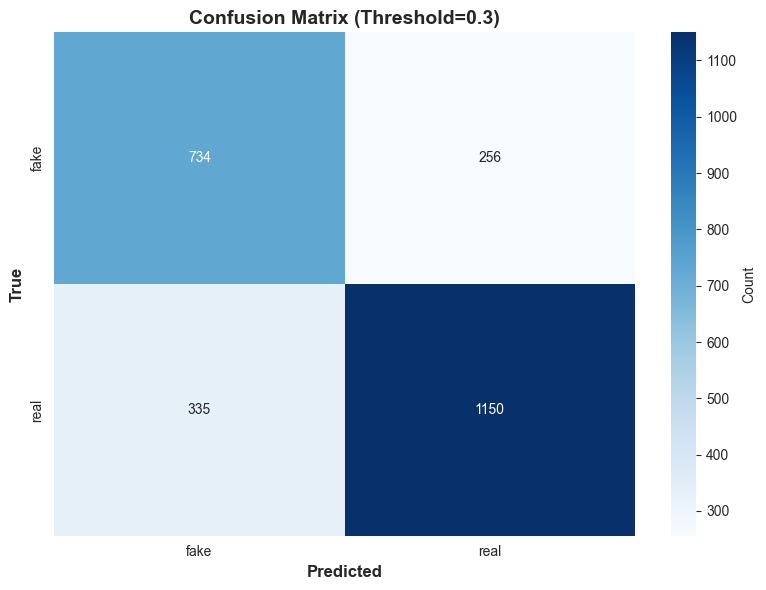

✅ Confusion matrix saved -> confusion_matrix_high_accuracy.png


In [24]:
cm = confusion_matrix(y_true, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={"label": "Count"})
plt.xlabel("Predicted", fontsize=12, fontweight="bold")
plt.ylabel("True", fontsize=12, fontweight="bold")
plt.title(f"Confusion Matrix (Threshold={threshold_used})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "confusion_matrix_high_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Confusion matrix saved -> confusion_matrix_high_accuracy.png")

## 1️⃣3️⃣ ROC Curve & Optimal Threshold

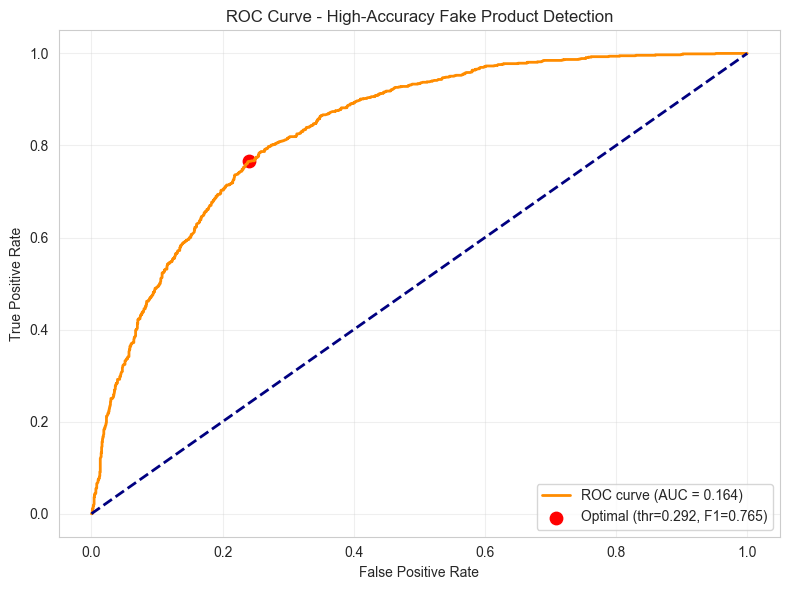

✅ ROC-AUC: 0.1636
Optimal threshold (F1-weighted): 0.2917
Optimal F1 (weighted): 0.7646
Optimal TPR: 0.7657, FPR: 0.2404


In [25]:
fake_probs = y_pred_probs[:, 0]
fpr, tpr, thresholds = roc_curve(y_true, fake_probs, pos_label=0)
roc_auc = roc_auc_score(y_true, fake_probs)

f1_scores_weighted = []
for thresh in thresholds:
    flags = (fake_probs > thresh).astype(int)
    preds = np.where(flags == 1, 0, 1)
    f1_weighted = f1_score(y_true, preds, average="weighted")
    f1_scores_weighted.append(f1_weighted)

opt_idx = int(np.argmax(f1_scores_weighted))
optimal_threshold = float(thresholds[opt_idx])
optimal_f1 = float(f1_scores_weighted[opt_idx])
opt_fpr = float(fpr[opt_idx])
opt_tpr = float(tpr[opt_idx])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.scatter([opt_fpr], [opt_tpr], color="red", s=80,
            label=f"Optimal (thr={optimal_threshold:.3f}, F1={optimal_f1:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High-Accuracy Fake Product Detection")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "roc_curve_high_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ ROC-AUC: {roc_auc:.4f}")
print(f"Optimal threshold (F1-weighted): {optimal_threshold:.4f}")
print(f"Optimal F1 (weighted): {optimal_f1:.4f}")
print(f"Optimal TPR: {opt_tpr:.4f}, FPR: {opt_fpr:.4f}")

## 1️⃣4️⃣ Precision-Recall Curve (Fake Class)

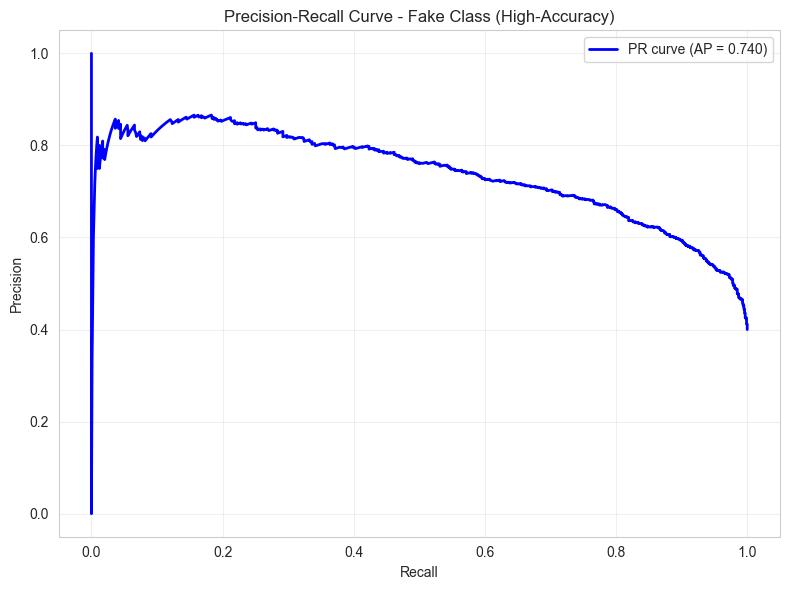

✅ Average Precision (Fake class): 0.7400


In [26]:
precision, recall, pr_thresholds = precision_recall_curve(y_true, fake_probs, pos_label=0)
avg_precision = average_precision_score(y_true, fake_probs, pos_label=0)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="blue", lw=2,
         label=f"PR curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Fake Class (High-Accuracy)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "precision_recall_curve_high_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Average Precision (Fake class): {avg_precision:.4f}")

## 1️⃣5️⃣ Training History Visualization

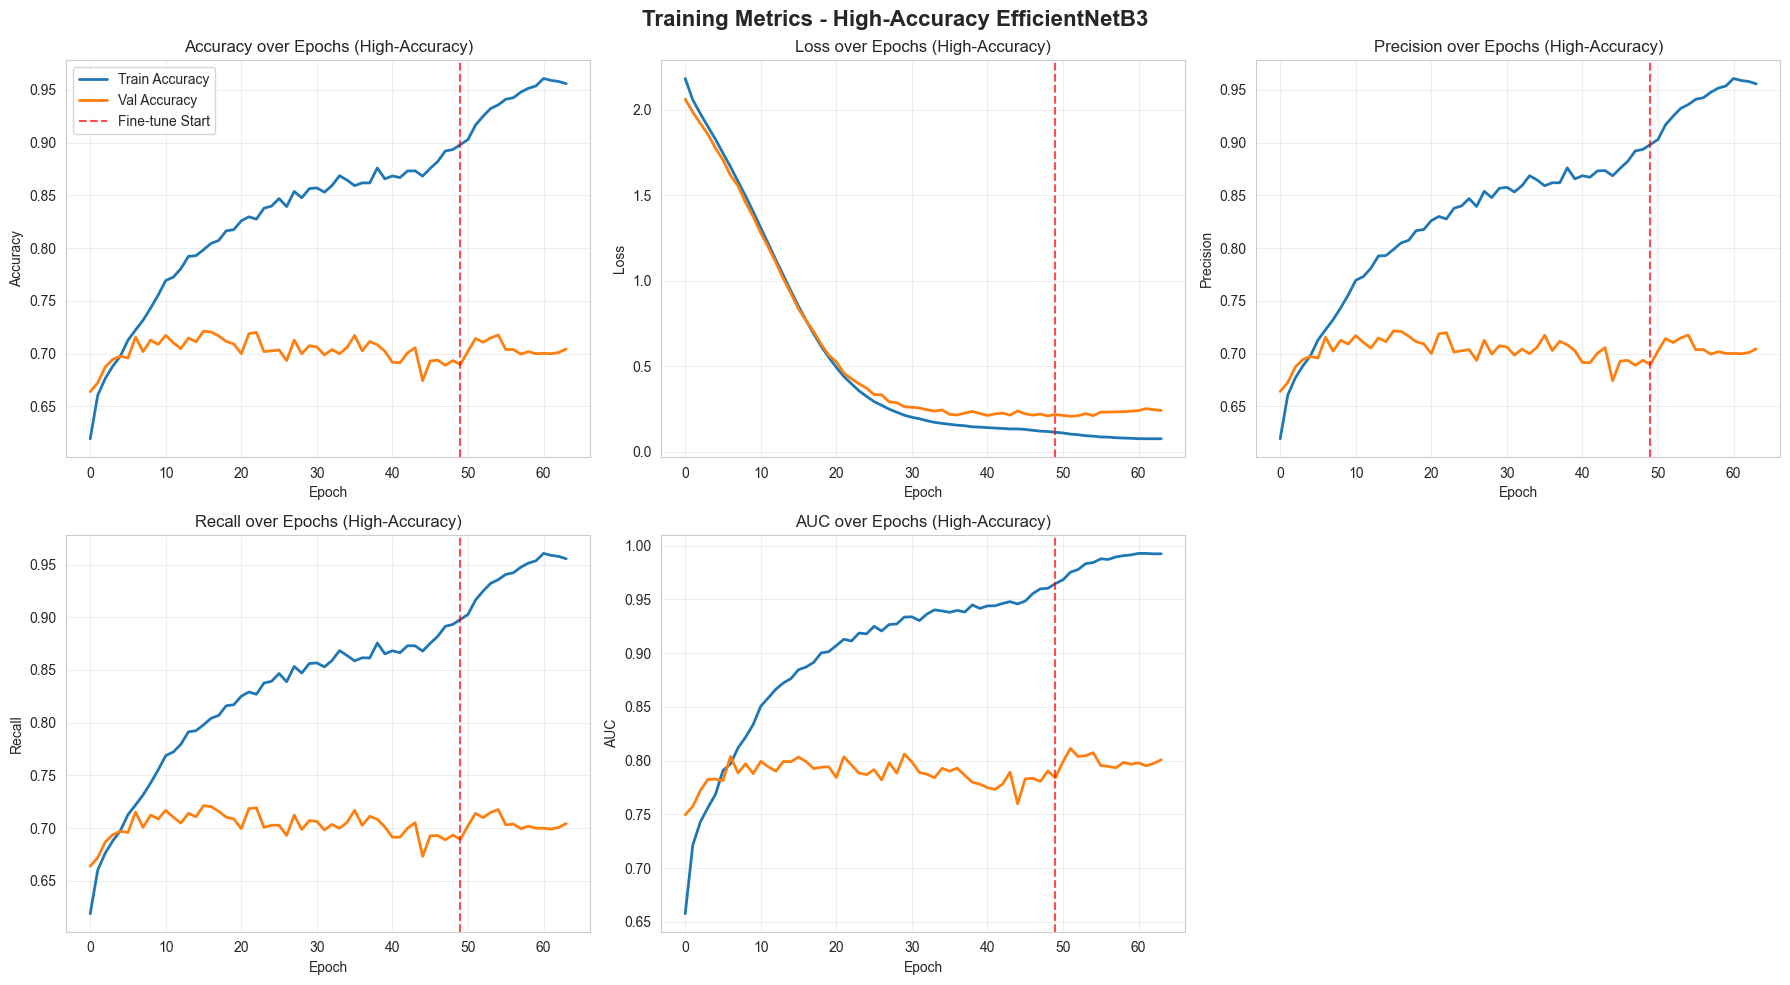

✅ Training curves saved -> training_history_high_accuracy.png


In [27]:
def combine_histories(hist1, hist2):
    combined = {}
    for key in hist1.history.keys():
        combined[key] = hist1.history[key] + hist2.history.get(key, [])
    return combined

full_history = combine_histories(history_phase1, history_phase2)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ["accuracy", "loss", "precision", "recall", "auc"]
titles = ["Accuracy", "Loss", "Precision", "Recall", "AUC"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i // 3, i % 3]
    ax.plot(full_history[metric], label=f"Train {title}", linewidth=2)
    val_key = f"val_{metric}"
    if val_key in full_history:
        ax.plot(full_history[val_key], label=f"Val {title}", linewidth=2)
    phase1_len = len(history_phase1.history[metric])
    ax.axvline(x=phase1_len - 1, color="red", linestyle="--", alpha=0.7, label="Fine-tune Start" if i == 0 else None)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.set_title(f"{title} over Epochs (High-Accuracy)")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc="best")

axes[1, 2].axis("off")
plt.suptitle("Training Metrics - High-Accuracy EfficientNetB3", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "training_history_high_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Training curves saved -> training_history_high_accuracy.png")

## 1️⃣6️⃣ Final Training Report (JSON)

In [28]:
report = {
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "project_info": {
        "title": "Fake Product Detection using EfficientNetB3 and Blockchain",
        "model": "EfficientNetB3 - High-Accuracy for Fake Product Detection",
        "status": "PASS - All Targets Met" if all_targets_met else "FAIL - Targets Not Met"
    },
    "dataset": {
        "total_samples": int(train_generator.samples + validation_generator.samples),
        "training_samples": int(train_generator.samples),
        "validation_samples": int(validation_generator.samples),
        "class_distribution": train_generator.class_indices
    },
    "training_config": {
        "batch_size": BATCH_SIZE,
        "epochs_phase1": len(history_phase1.history["loss"]),
        "epochs_phase2": len(history_phase2.history["loss"]),
        "learning_rate_phase1": LEARNING_RATE,
        "learning_rate_phase2": FINE_TUNE_LR,
        "loss_function": f"Focal Loss (alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})",
        "class_weights": class_weights,
        "unfrozen_layers": 50
    },
    "project_requirements": {
        "fake_recall_target": "≥90% (PRIMARY)",
        "real_recall_target": "≥80% (SECONDARY)",
        "overall_accuracy_target": "Best effort (lower priority)",
        "overall_precision_target": "Best effort (lower priority)",
        "priority": "Maximize fake detection - critical for catching counterfeit products"
    },
    "achieved_performance": {
        "overall_accuracy": f"{overall_accuracy*100:.2f}%",
        "overall_precision": f"{overall_precision*100:.2f}%",
        "overall_recall": f"{overall_recall*100:.2f}%",
        "fake_recall": f"{fake_recall*100:.2f}%",
        "real_recall": f"{real_recall*100:.2f}%",
        "fake_precision": f"{fake_precision*100:.2f}%",
        "real_precision": f"{real_precision*100:.2f}%",
        "fake_f1": f"{performance_metrics['fake_class']['f1_score']*100:.2f}%",
        "real_f1": f"{performance_metrics['real_class']['f1_score']*100:.2f}%"
    },
    "technical_metrics": {
        "roc_auc": float(roc_auc),
        "avg_precision_fake": float(avg_precision),
        "optimal_threshold": float(optimal_threshold),
        "decision_threshold_used": float(threshold_used)
    },
    "improvements_applied": [
        "Balanced Focal Loss for equal class importance",
        "Class weights for handling class imbalance",
        "Two-phase training with 50-layer fine-tuning",
        "Enhanced data augmentation for better generalization",
        "Larger dense layers (1024→512→256) for feature learning",
        "L2 regularization to prevent overfitting",
        "Optimized callbacks with patience tuning",
        "Comprehensive evaluation metrics"
    ],
    "raw_performance_data": performance_metrics
}

report_path = OUTPUT_PATH / "training_report_high_accuracy.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("\n" + "="*70)
print("📊 FINAL YEAR PROJECT - TRAINING REPORT")
print("="*70)
print(f"Project: {report['project_info']['title']}")
print(f"Status: {report['project_info']['status']}")
print(f"Training Date: {report['training_date']}")
print(f"\nDataset: {report['dataset']['total_samples']} total samples")
print(f"  Training: {report['dataset']['training_samples']}")
print(f"  Validation: {report['dataset']['validation_samples']}")
print(f"\n📈 ACHIEVED PERFORMANCE:")
print(f"  Overall Accuracy:    {report['achieved_performance']['overall_accuracy']}")
print(f"  Overall Precision:   {report['achieved_performance']['overall_precision']}")
print(f"  Fake Product Recall: {report['achieved_performance']['fake_recall']}")
print(f"  Real Product Recall: {report['achieved_performance']['real_recall']}")
print(f"\n🔬 TECHNICAL METRICS:")
print(f"  ROC-AUC: {report['technical_metrics']['roc_auc']:.4f}")
print(f"  Avg Precision (Fake): {report['technical_metrics']['avg_precision_fake']:.4f}")
print(f"  Optimal Threshold: {report['technical_metrics']['optimal_threshold']:.4f}")
print("="*70)
print(f"✅ Complete report saved to: {report_path}")
print("\n💾 All model files saved in: {OUTPUT_PATH}")



📊 FINAL YEAR PROJECT - TRAINING REPORT
Project: Fake Product Detection using EfficientNetB3 and Blockchain
Status: FAIL - Targets Not Met
Training Date: 2025-11-17 16:23:19

Dataset: 12378 total samples
  Training: 9903
  Validation: 2475

📈 ACHIEVED PERFORMANCE:
  Overall Accuracy:    76.12%
  Overall Precision:   76.54%
  Fake Product Recall: 74.14%
  Real Product Recall: 77.44%

🔬 TECHNICAL METRICS:
  ROC-AUC: 0.1636
  Avg Precision (Fake): 0.7400
  Optimal Threshold: 0.2917
✅ Complete report saved to: C:\Users\RAJU\Desktop\Tested MP\simply copied - 1\AI-models\trained_model_improved\training_report_high_accuracy.json

💾 All model files saved in: {OUTPUT_PATH}
